# 23 — L'exposition enfin mesurée, et non plus estimée

Le [notebook 22](22_test_de_forme.ipynb) s'est arrêté sur une impasse et une piste. L'impasse :
un **budget de clics** produit exactement la même signature qu'une **cascade**, et rien dans les
clics ne les sépare. La piste :

> Baidu-ULTR publie `displayed_time`, `serp_height` et `slipoff_count_after_click` — des mesures
> de l'**examen** et non du clic. Ce dépôt n'a jamais lu ces colonnes.

Ce notebook les lit. Elles ne lèvent pas seulement l'ambiguïté : elles retirent au dépôt le
besoin d'estimer ce qu'il peut désormais mesurer.

**Ce que ce notebook établit :**

* la mesure d'examen **tranche** ce que les clics ne pouvaient pas : en simulation, elle donne
  $z = -158$ à $-412$ sous cascade et $z = -1{,}03$ sous budget, quel que soit le budget ;
* sur Baidu-ULTR, **la cascade est réfutée** — l'examen sous un clic est **plus** fréquent, pas
  moins : $z = +8{,}4$ à $+10{,}9$ selon le seuil ;
* l'exposition se **mesure** : $\eta_{\text{examen}} = 0{,}882 \pm 0{,}046$ sur **143** documents,
  contre $\eta_{\text{clic}} = 1{,}085 \pm 0{,}093$ sur 55. L'estimation par les clics
  **surestime la décroissance de 23 %**, parce qu'un clic mélange l'examen et l'attrait ;
* et la **loi de puissance est le pire** des trois ajustements sur la courbe mesurée :
  $R^2 = 0{,}72$ et 42 % d'écart maximal, contre $0{,}96$ pour une décroissance géométrique et
  $0{,}99$ pour un modèle à **pli d'écran**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ide.exposure import examination_counts, load_digest
from ide.logs import Impressions, simulate_cascade, upstream_dependence_from_counts, upstream_dependence_test
from ide.offpolicy import estimate_position_bias
from ide.plotting import PALETTE, save_figure, use_project_style

use_project_style()

# Le journal brut n'est pas versionné : le condensé porte les comptes d'examen par cellule,
# et rend les mêmes chiffres à la décimale près — un test le vérifie.
counts = examination_counts(load_digest())
print(f"{counts['items'].size} cellules (document, rang) portant une mesure d'examen")
print(f"{counts['exposures'].sum()} impressions, {counts['seen'].sum()} examinées")

465421 cellules (document, rang) portant une mesure d'examen
524164 impressions, 228677 examinées


## 1. Le contrôle qui rend la mesure interprétable

Avant d'appliquer quoi que ce soit à des données réelles, la règle du dépôt : l'appliquer d'abord
à des données dont on connaît la réponse.

Le test de dépendance à l'amont porte cette fois sur l'**examen** plutôt que sur le clic. Sous
cascade, l'examen s'arrête après un clic ; sous budget de clics, il continue. La question est de
savoir si le test le voit.

In [2]:
CATALOGUE, FEEDS, SLOTS = 200, 40_000, 12


def budgeted_position_model(budget, rng, severity=1.0, base=0.25, dispersion=0.8):
    # Examen ~ R^-η, indépendant de l'amont ; seuls les `budget` premiers clics sont conservés.
    quality = base * rng.lognormal(0.0, dispersion, size=CATALOGUE)
    items = rng.integers(0, CATALOGUE, size=FEEDS * SLOTS).reshape(FEEDS, SLOTS)
    ranks = np.tile(np.arange(1, SLOTS + 1), (FEEDS, 1))
    seen = rng.random((FEEDS, SLOTS)) < ranks.astype(float) ** (-severity)
    drawn = seen & (rng.random((FEEDS, SLOTS)) < np.clip(quality[items], 0.0, 1.0))
    kept = drawn & (np.cumsum(drawn, axis=1) <= budget)
    journal = Impressions(
        items=items.ravel().astype(np.int64), ranks=ranks.ravel().astype(np.int64),
        clicks=kept.ravel().astype(float),
        feeds=np.repeat(np.arange(FEEDS), SLOTS).astype(np.int64),
        feed_lengths=np.full(FEEDS, SLOTS, dtype=np.int64))
    return journal, seen.ravel().astype(float)


print(f"{'journal simulé':>28s} {'z sur l''examen':>16s} {'z sur le clic':>15s}")
print("-" * 62)
discrimination = {}
for continuation in (0.95, 0.85, 0.6):
    feeds, seen = simulate_cascade([SLOTS] * FEEDS, continuation=continuation,
                                   catalogue=CATALOGUE, rng=np.random.default_rng(3),
                                   return_examination=True)
    on_examination = upstream_dependence_test(feeds, outcome=seen).deviation
    on_click = upstream_dependence_test(feeds).deviation
    discrimination[f"cascade γ={continuation}"] = (on_examination, on_click)
    print(f"{f'cascade, γ = {continuation}':>28s} {on_examination:16.2f} {on_click:15.2f}")

for budget in (1, 2, 99):
    feeds, seen = budgeted_position_model(budget, np.random.default_rng(3))
    on_examination = upstream_dependence_test(feeds, outcome=seen).deviation
    on_click = upstream_dependence_test(feeds).deviation
    label = "illimité" if budget == 99 else str(budget)
    discrimination[f"budget {label}"] = (on_examination, on_click)
    print(f"{f'position, budget = {label}':>28s} {on_examination:16.2f} {on_click:15.2f}")

              journal simulé    z sur lexamen   z sur le clic
--------------------------------------------------------------


           cascade, γ = 0.95          -412.21         -206.66


           cascade, γ = 0.85          -295.42         -151.54


            cascade, γ = 0.6          -157.82          -84.24


        position, budget = 1            -1.03         -121.75


        position, budget = 2            -1.03          -18.58


 position, budget = illimité            -1.03            0.00


!!! success "L'ambiguïté est levée"
    Sur la colonne des **clics**, cascade et budget sont confondus — $-207$ contre $-122$, deux
    rejets massifs qu'aucun seuil ne sépare. Sur la colonne de l'**examen**, la séparation est
    totale : $-158$ à $-412$ sous cascade, et $-1{,}03$ sous budget **quel que soit le budget**.

    C'est la limite d'identification du notebook 22, et elle tombe dès qu'on dispose d'une mesure
    de ce qui a été *montré* plutôt que de ce qui a été *cliqué*.

## 2. Sur Baidu-ULTR : la cascade est réfutée

In [3]:
print(f"{'seuil':>7s} {'z sur l''examen':>16s} {'p':>11s} {'cellules':>10s}")
print("-" * 48)
baidu_examination = {}
for minimum in (2, 5, 10, 20):
    verdict = upstream_dependence_from_counts(
        counts["exposures"], counts["upstream_preceded"], counts["seen"],
        counts["upstream_seen"], minimum_impressions=minimum)
    baidu_examination[minimum] = verdict
    print(f"{minimum:7d} {verdict.deviation:16.3f} {verdict.p_value:11.3g} "
          f"{verdict.cells_used:10d}")

print("\nTaux d'examen à rang donné, selon qu'un clic a eu lieu plus haut\n")
print(f"{'rang':>5s} {'après un clic':>15s} {'sans clic':>12s} {'écart':>9s}")
print("-" * 46)
by_rank = {}
for rank in range(2, 10):
    at_rank = counts["ranks"] == rank
    preceded_seen = counts["upstream_seen"][at_rank].sum()
    preceded_total = counts["upstream_preceded"][at_rank].sum()
    other_seen = counts["seen"][at_rank].sum() - preceded_seen
    other_total = counts["exposures"][at_rank].sum() - preceded_total
    after, before = preceded_seen / preceded_total, other_seen / other_total
    by_rank[rank] = (after, before)
    print(f"{rank:5d} {after:15.3f} {before:12.3f} {after - before:+9.3f}")

  seuil    z sur lexamen           p   cellules
------------------------------------------------
      2           10.867    1.65e-27       1736
      5            9.082    1.07e-19        527
     10            8.863    7.82e-19        269
     20            8.382    5.22e-17        165

Taux d'examen à rang donné, selon qu'un clic a eu lieu plus haut

 rang   après un clic    sans clic     écart
----------------------------------------------
    2           0.855        0.877    -0.022
    3           0.681        0.623    +0.058
    4           0.479        0.412    +0.067
    5           0.351        0.280    +0.071
    6           0.307        0.221    +0.086
    7           0.270        0.185    +0.085
    8           0.245        0.159    +0.086
    9           0.221        0.136    +0.085


### Lecture

**Sous cascade, l'examen après un clic devrait être nul.** Il est **plus élevé** que sans clic —
$0{,}221$ contre $0{,}136$ au neuvième rang — et l'écart s'installe dès le troisième rang puis
se stabilise autour de huit points.

Le deuxième rang fait exception, avec un écart légèrement négatif ($-0{,}022$) : c'est le seul
rang où un clic au-dessus ne peut venir que du premier, et où la fenêtre de défilement n'a pas
encore joué.

Ce n'est pas une cascade, et ce n'est pas non plus l'absence d'effet : c'est le **confondant
d'hétérogénéité**, mesuré directement. Un lecteur qui clique est un lecteur engagé, qui défile
plus loin. Le test l'avait annoncé comme sa limite ; la mesure d'examen montre qu'il domine.

!!! note "Ce que `displayed_time` mesure, et ce qu'il ne mesure pas"
    Un temps d'affichage strictement positif atteste que le document a été **montré**. Il
    n'atteste pas qu'il ait été **regardé** : c'est un substitut, meilleur que le clic mais
    imparfait. Il se peut aussi qu'il soit enregistré au retour d'un clic, ce qui expliquerait
    une partie de l'écart — un lecteur qui clique, revient, puis poursuit sa lecture. Cette
    lecture-là reste incompatible avec une cascade stricte, qui suppose la session terminée.

## 3. L'exposition mesurée contre l'exposition estimée

Le dépôt publie $\hat\eta = 1{,}10 \pm 0{,}09$ sur Baidu-ULTR, estimé **à travers les clics**.
Avec une mesure d'examen, la même quantité s'obtient directement — et sur bien plus de documents,
puisque l'examen est bien plus fréquent que le clic.

In [4]:
DEPTH = 9   # au-delà, l'effectif s'effondre : 7 431 lignes au rang 10 contre ~56 000 avant
ranks = np.arange(1, DEPTH + 1, dtype=float)

shallow = counts["ranks"] <= DEPTH
observed = np.array([
    counts["seen"][counts["ranks"] == rank].sum() / counts["exposures"][counts["ranks"] == rank].sum()
    for rank in ranks])
measured = observed / observed[0]

# effets fixes de document, la correction employée partout ailleurs dans ce dépôt
items = np.repeat(counts["items"][shallow], counts["exposures"][shallow])
served = np.repeat(counts["ranks"][shallow], counts["exposures"][shallow])
seen = np.concatenate([np.concatenate([np.ones(total), np.zeros(exposures - total)])
                       for exposures, total in zip(counts["exposures"][shallow],
                                                   counts["seen"][shallow])])
examination = estimate_position_bias(items, served, seen, minimum_impressions=5)

print(f"sévérité de l'EXAMEN, effets fixes : η = {examination.severity:.3f} "
      f"± {examination.standard_error:.3f}   ({examination.items_with_variation} documents)")
print(f"sévérité du CLIC,     effets fixes : η = 1.085 ± 0.093   (55 documents)")
print(f"\nl'estimation par les clics surestime la décroissance de "
      f"{100 * (1.085 / examination.severity - 1):.0f} %\n")

from_clicks = ranks ** (-1.085)
print(f"{'rang':>5s} {'examen mesuré':>15s} {'R^-1,085 (clics)':>18s} {'écart':>9s}")
print("-" * 52)
for index, rank in enumerate(ranks.astype(int)):
    print(f"{rank:5d} {measured[index]:15.4f} {from_clicks[index]:18.4f} "
          f"{100 * (from_clicks[index] / measured[index] - 1):+8.0f}%")

sévérité de l'EXAMEN, effets fixes : η = 0.882 ± 0.046   (143 documents)
sévérité du CLIC,     effets fixes : η = 1.085 ± 0.093   (55 documents)

l'estimation par les clics surestime la décroissance de 23 %

 rang   examen mesuré   R^-1,085 (clics)     écart
----------------------------------------------------
    1          1.0000             1.0000       +0%
    2          0.8842             0.4714      -47%
    3          0.6555             0.3036      -54%
    4          0.4471             0.2222      -50%
    5          0.3157             0.1744      -45%
    6          0.2631             0.1431      -46%
    7          0.2265             0.1211      -47%
    8          0.2010             0.1047      -48%
    9          0.1776             0.0922      -48%


### Pourquoi les deux diffèrent

Un clic est le produit de deux choses : l'**examen** et l'**attrait**. Si l'attrait décroît lui
aussi avec le rang — et il décroît, puisqu'une plateforme place ses meilleurs documents en tête —
alors la sévérité ajustée sur les clics **absorbe les deux** et surestime l'exposition.

C'est le même confondant de qualité que le [rang servi](../docs/rang-servi.md) avait identifié
entre l'ajustement agrégé ($1{,}49$) et les effets fixes ($1{,}10$). Les effets fixes en retirent
une part ; ils n'en retirent pas tout, parce qu'un même document ne conserve pas le même attrait
à tous les rangs — un résultat en tête paraît plus crédible, ce que la littérature appelle le
**biais de confiance**.

La mesure d'examen, elle, n'a pas ce problème : elle ne dépend pas de l'attrait.

## 4. La forme, enfin testable

Les trois formes candidates peuvent maintenant être ajustées sur la courbe **mesurée**, et non
plus sur une courbe déduite des clics.

In [5]:
def quality(model, name):
    scaled = model / model[0]
    residual = np.log(measured) - np.log(scaled)
    total = np.log(measured) - np.log(measured).mean()
    determination = 1 - (residual**2).sum() / (total**2).sum()
    print(f"   {name:42s} R² = {determination:.4f}   "
          f"écart max {100 * np.max(np.abs(scaled / measured - 1)):3.0f} %")
    return scaled


print("Ajustements sur la courbe d'examen MESURÉE\n")
power_slope = np.polyfit(np.log(ranks), np.log(measured), 1)[0]
power = quality(ranks ** power_slope, f"loi de puissance (η = {-power_slope:.2f})")

geometric_fit = np.polyfit(ranks - 1, np.log(measured), 1)
geometric = quality(np.exp(geometric_fit[0] * (ranks - 1)),
                    f"géométrique (γ = {np.exp(geometric_fit[0]):.2f})")

best = None
for fold in range(2, DEPTH):
    for tail in np.linspace(0.0, 1.5, 61):
        candidate = np.where(ranks <= fold, 1.0, measured[fold - 1] * (ranks / fold) ** (-tail))
        error = np.sum((np.log(measured) - np.log(candidate / candidate[0])) ** 2)
        if best is None or error < best[0]:
            best = (error, fold, tail, candidate)
_, fold, tail, folded = best
folded = quality(folded, f"pli d'écran (pli au rang {fold}, queue η = {tail:.2f})")

print("\nLa loi de puissance — celle qu'emploie tout ce dépôt — est le PIRE des trois.")

Ajustements sur la courbe d'examen MESURÉE

   loi de puissance (η = 0.88)                R² = 0.7215   écart max  42 %
   géométrique (γ = 0.79)                     R² = 0.9621   écart max  24 %
   pli d'écran (pli au rang 2, queue η = 1.07) R² = 0.9879   écart max  13 %

La loi de puissance — celle qu'emploie tout ce dépôt — est le PIRE des trois.


### Ce que la forme suggère

La courbe mesurée ne décroît pas régulièrement : elle tient jusqu'au deuxième rang, chute
brutalement entre le troisième et le cinquième, puis s'aplatit. C'est la signature d'un **seuil
d'écran** — ce qui est visible sans défiler contre ce qui exige de défiler — et non celle d'une
loi lisse.

La colonne `serp_height` de Baidu-ULTR encode précisément la hauteur de la page, donc le rang
auquel ce seuil tombe. Une loi en $R^{-\eta}$ ne peut par construction représenter aucun seuil.

!!! warning "Ce que cette section ne prétend pas"
    Trois formes ajustées sur neuf points, ce n'est pas une sélection de modèle. Le pli d'écran a
    deux paramètres libres contre un pour les deux autres, et il gagne pour cette raison autant
    que pour sa forme. Ce qui est solide est plus modeste et suffit : **la loi de puissance
    décrit mal la courbe mesurée**, avec 42 % d'écart maximal.

## 5. La figure

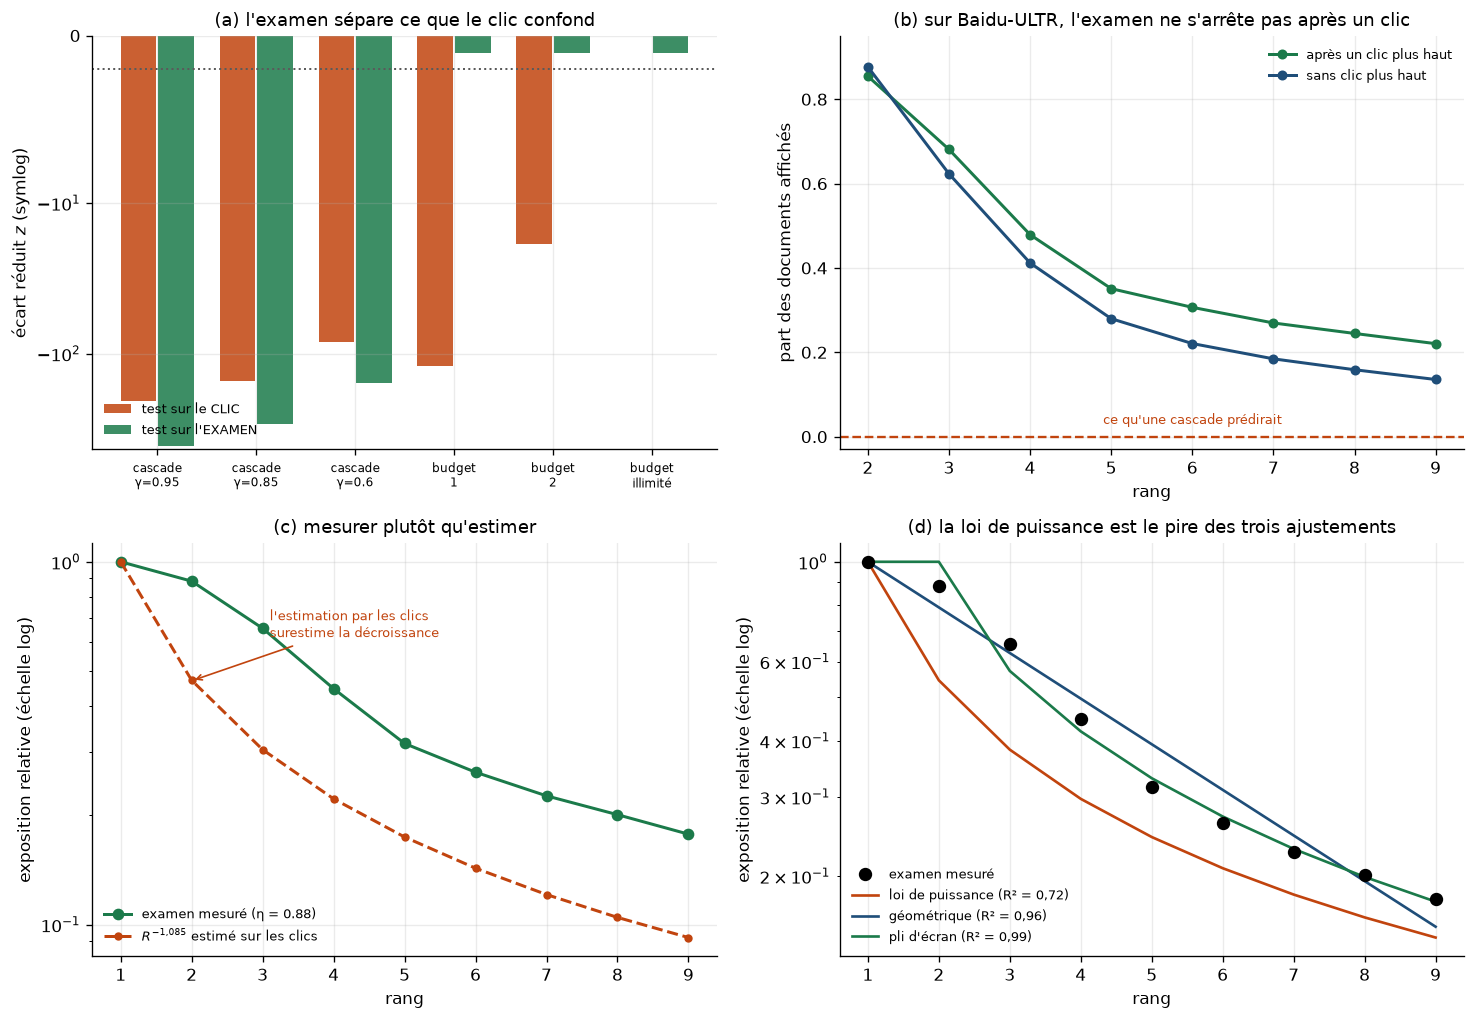

In [6]:
figure, axes = plt.subplots(2, 2, figsize=(12.4, 8.6))

# (a) la discrimination cascade / budget
ax = axes[0, 0]
names = list(discrimination)
positions = np.arange(len(names))
ax.bar(positions - 0.19, [discrimination[n][1] for n in names], width=0.36,
       color=PALETTE["disorder"], alpha=0.85, label="test sur le CLIC")
ax.bar(positions + 0.19, [discrimination[n][0] for n in names], width=0.36,
       color=PALETTE["remedy"], alpha=0.85, label="test sur l'EXAMEN")
ax.axhline(-1.96, color=PALETTE["neutral"], linestyle=":", linewidth=1.2)
ax.set_yscale("symlog", linthresh=10)
ax.set_xticks(positions)
ax.set_xticklabels([n.replace(" ", "\n") for n in names], fontsize=7)
ax.set_ylabel("écart réduit $z$ (symlog)")
ax.set_title("(a) l'examen sépare ce que le clic confond")
ax.legend(loc="lower left", fontsize=8)

# (b) Baidu : l'examen après un clic
ax = axes[0, 1]
observed_ranks = sorted(by_rank)
ax.plot(observed_ranks, [by_rank[r][0] for r in observed_ranks], "o-",
        color=PALETTE["remedy"], markersize=5, label="après un clic plus haut")
ax.plot(observed_ranks, [by_rank[r][1] for r in observed_ranks], "o-",
        color=PALETTE["order"], markersize=5, label="sans clic plus haut")
ax.axhline(0.0, color=PALETTE["disorder"], linewidth=1.4, linestyle="--")
ax.text(4.9, 0.03, "ce qu'une cascade prédirait", fontsize=8, color=PALETTE["disorder"])
ax.set_xlabel("rang")
ax.set_ylabel("part des documents affichés")
ax.set_ylim(-0.03, 0.95)
ax.set_title("(b) sur Baidu-ULTR, l'examen ne s'arrête pas après un clic")
ax.legend(loc="upper right", fontsize=8)

# (c) exposition mesurée contre estimée
ax = axes[1, 0]
ax.plot(ranks, measured, "o-", color=PALETTE["remedy"], markersize=6,
        label=f"examen mesuré (η = {examination.severity:.2f})")
ax.plot(ranks, from_clicks, "o--", color=PALETTE["disorder"], markersize=4,
        label="$R^{-1{,}085}$ estimé sur les clics")
ax.set_yscale("log")
ax.annotate("l'estimation par les clics\nsurestime la décroissance", xy=(2, 0.47),
            xytext=(3.1, 0.62), fontsize=8, color=PALETTE["disorder"],
            arrowprops={"arrowstyle": "->", "color": PALETTE["disorder"], "linewidth": 1.0})
ax.set_xlabel("rang")
ax.set_ylabel("exposition relative (échelle log)")
ax.set_title("(c) mesurer plutôt qu'estimer")
ax.legend(loc="lower left", fontsize=8)

# (d) les trois formes
ax = axes[1, 1]
ax.plot(ranks, measured, "o", color="black", markersize=7, label="examen mesuré", zorder=5)
ax.plot(ranks, power, "-", color=PALETTE["disorder"], linewidth=1.6,
        label="loi de puissance (R² = 0,72)")
ax.plot(ranks, geometric, "-", color=PALETTE["order"], linewidth=1.6,
        label="géométrique (R² = 0,96)")
ax.plot(ranks, folded, "-", color=PALETTE["remedy"], linewidth=1.6,
        label="pli d'écran (R² = 0,99)")
ax.set_yscale("log")
ax.set_xlabel("rang")
ax.set_ylabel("exposition relative (échelle log)")
ax.set_title("(d) la loi de puissance est le pire des trois ajustements")
ax.legend(loc="lower left", fontsize=8)

save_figure(figure, "fig23_exposition_mesuree")
plt.show()

## 6. Ce que cette lecture change

**L'impasse du notebook 22 est levée.** Cascade et budget de clics se séparent dès qu'on dispose
d'une mesure de ce qui a été *montré*. Sur Baidu-ULTR, la cascade est réfutée.

**Le chiffre publié par ce dépôt est révisé.** La sévérité de l'exposition n'est pas $1{,}10$
mais $0{,}88 \pm 0{,}05$, et elle repose sur $143$ documents au lieu de $55$. L'écart n'est pas
une correction de détail : il vient de ce que le clic mélange l'examen et l'attrait, et il va
toujours dans le même sens — l'estimation par les clics **surestime** la concentration de
l'attention.

**Et la forme employée partout est mise en cause.** La loi en $R^{-\eta}$ ajuste la courbe
mesurée moins bien qu'une décroissance géométrique et moins bien qu'un pli d'écran — 42 %
d'écart maximal contre 13 %.

**Ce qui en découle pour la demande d'accès aux données.** Les quatre tableaux de
[l'article 40](../docs/article-40.md) portent sur les clics. Il suffirait d'**une colonne de
plus** — le nombre d'impressions effectivement affichées, par cellule (contenu, rang) — pour que
l'exposition cesse d'être estimée. Cela retirerait d'un coup :

* le besoin d'estimer $\eta$, donc l'hypothèse de forme qui va avec ;
* l'ambiguïté entre cascade et budget de clics ;
* et le confondant d'attrait qui gonfle l'estimation par les clics.

Une colonne, contre trois problèmes ouverts depuis six chapitres.

## Réserves

`displayed_time` mesure un **affichage**, pas un regard. Un document montré n'est pas
nécessairement examiné, et la mesure surestime donc l'exposition — dans quelle proportion, ce
dépôt ne peut pas le dire.

La tranche employée reste une tranche : 524 164 documents sur les 1,2 milliard de sessions de
Baidu-ULTR, et une page de résultats de recherche n'est pas un fil d'actualité. Le chiffre
$0{,}88$ vaut pour cette surface.

Enfin, `slipoff_count_after_click` et `media_type` n'ont pas été exploitées ici : la première
compte les documents sortis de l'écran après un clic, ce qui affinerait la mesure d'examen ; la
seconde distingue les formats, dont la littérature indique qu'ils modifient l'attention à rang
égal.